# Introduction

This notebook is intended for a closer look at the mechanisms of "monoGRU" architectures.

We show that these fit subject's data with minimal variability in internal mechanisms.
This let's us reduce the model to a 'cannonical form', with a common computation which we study here.

In [1]:
## setup ##
import os
os.chdir('/ceph/behrens/wsilver/reversal/code/')

from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
from NM_TinyRNN.code.measures import plotting_stats
from NM_TinyRNN.code.measures import performance as perf
from NM_TinyRNN.code.measures import reversal_metrics as rev

from NM_TinyRNN.code.models import submit_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

In [28]:
#construct analysis_df and have a look at a subset of data!
info_df = submit_jobs.get_DA_info_df(folder_name = 'nested_DA_8') #code used to submit jobs
all_models_df = analysis.get_analysis_df(info_df, mode='all') #code to aggregate all paths and some data
performance_df = perf.get_performance_df(all_models_df) #code to recompute evaluations and aggregate
best_model_df = perf.select_best_outer(performance_df) #
subject_level_df = perf.compute_outer_mean(best_model_df)

print("Available model types (model_type2):")
print(all_models_df.model_type2.unique())

print("\nAvailable columns:")
print([col for col in all_models_df.columns if 'CE' in col or 'type' in col])


Loaded analysis paths from cache: NM_TinyRNN/data/analysis/analysis_df_nested_DA_8_final.htsv
Loaded performance dataframe from cache: NM_TinyRNN/data/analysis/performance_df_nested_DA_8_final.htsv
Available model types (model_type2):
['GRU+BC' 'GRU+BC-DB' 'GRU' 'monoGRU+BC' 'monoGRU+BC-DB']

Available columns:
['model_type', 'model_type2']


## Examples from subjects

Let's have a look at the hidden states across all subjects. The should carry an overall motif which we will investigate at the level of network parameters.


<Axes: xlabel='logit_past', ylabel='logit_change'>

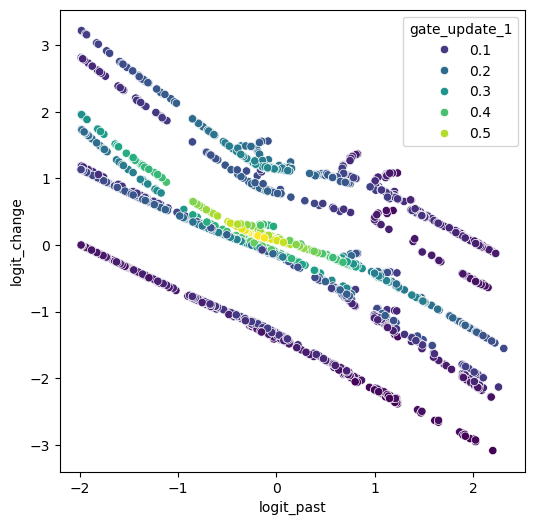

In [4]:
# single subject example
subject_id="WS05"
model_id = "2_unit_monoGRU_relu_unipolar_forced"
outer_loop_n = 10
select_df = best_model_df.query(f"subject_id=='{subject_id}' and model_id=='{model_id}' and outer_loop_n=={outer_loop_n}")

fig, ax = plt.subplots(1,1,figsize=(6,6))
trials_data = analysis.load_data(select_df.trials_data_path.iloc[0])
model = analysis.load_data(select_df.model_pickle_path.iloc[0])
sns.scatterplot(trials_data, x= 'logit_past',y='logit_change', hue='gate_update_1',palette='viridis')

<Axes: xlabel='reversal_trial_index', ylabel='choice'>

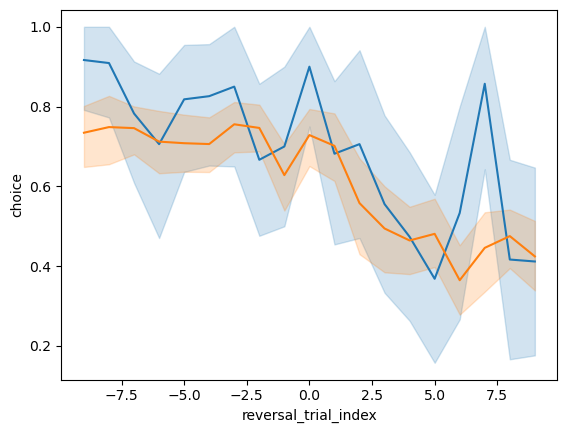

In [60]:
# we want to plot behaviour around reversals
reload(rev)
test = rev.add_reversal_columns(trials_data)
test['prob_A'] = test.groupby('session_folder_name', sort=False)['prob_A'].shift(1)
test['prob_B'] = test.groupby('session_folder_name', sort=False)['prob_B'].shift(1)
test = test.query('forced_choice == 0')
fig, ax = plt.subplots()
sns.lineplot(test.query('reversal_type=="RL" and reversal_trial_index>-10 and reversal_trial_index<10'),
             x='reversal_trial_index',
             y='choice',
             ax=ax)
sns.lineplot(test.query('reversal_type=="RL" and reversal_trial_index>-10 and reversal_trial_index<10'),
             x='reversal_trial_index',
             y='prob_B',
             ax=ax)


[Text(0.5, 0, 'Trial relative to reversal'),
 Text(0, 0.5, 'P(choose best initial arm)')]

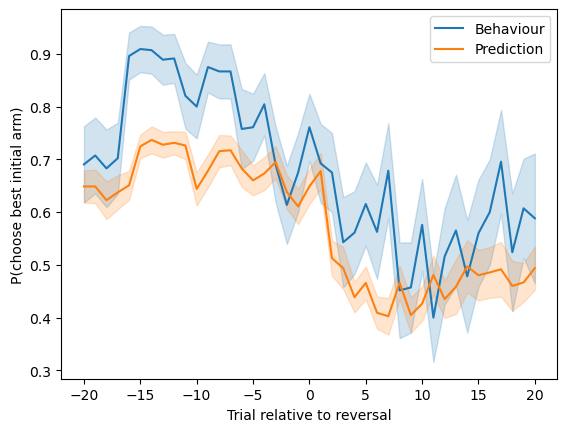

In [61]:
reload(rev)

reversal_data = rev.collapse_reversal_data(trials_data)
reversal_data = reversal_data.query('forced_choice == 0')
fig, ax = plt.subplots()
sns.lineplot(reversal_data, x='reversal_trial_index', y='choice_initial', errorbar='se', ax=ax, label='Behaviour')
sns.lineplot(reversal_data, x='reversal_trial_index', y='prob_initial', errorbar='se', ax=ax, label='Prediction')
ax.set(xlabel='Trial relative to reversal', ylabel='P(choose best initial arm)')


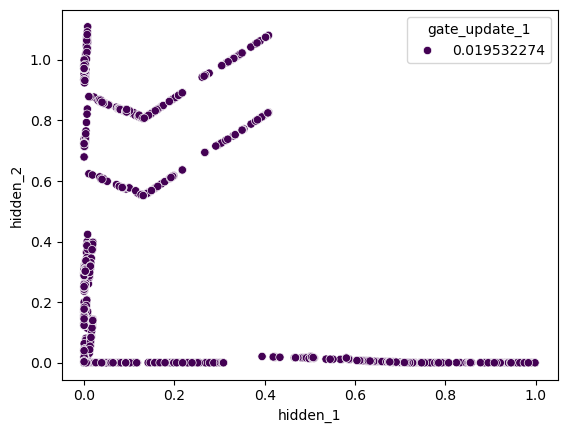

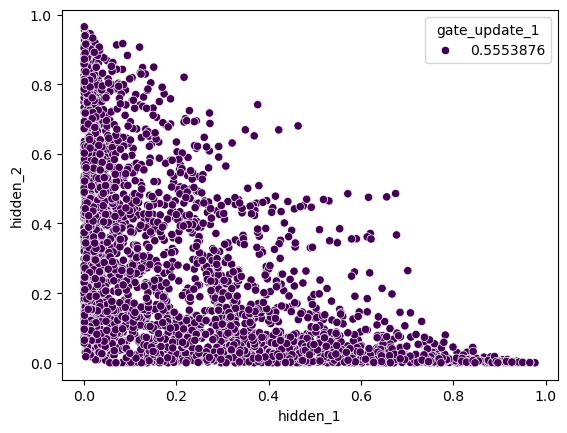

In [62]:
# we want to run the model through twice
reload(rev)
(z_low, z_high) = trials_data.gate_update_1.quantile([0.01,0.99]).values
trials_data_files = []
for z in [z_low, z_high]:
    z_tensor = torch.tensor(z,dtype =torch.float32).unsqueeze(0).unsqueeze(0)
    fixed_gates = {'z_t':z_tensor}
    trials_data_new = rev._run_model_on_trials_data(model,trials_data, fixed_gates = fixed_gates)
    trials_data_files.append(trials_data_new)
    sns.scatterplot(x=trials_data_new['hidden_1'], y=trials_data_new['hidden_2'], 
                hue=trials_data_new['gate_update_1'], palette='viridis')
    plt.show()



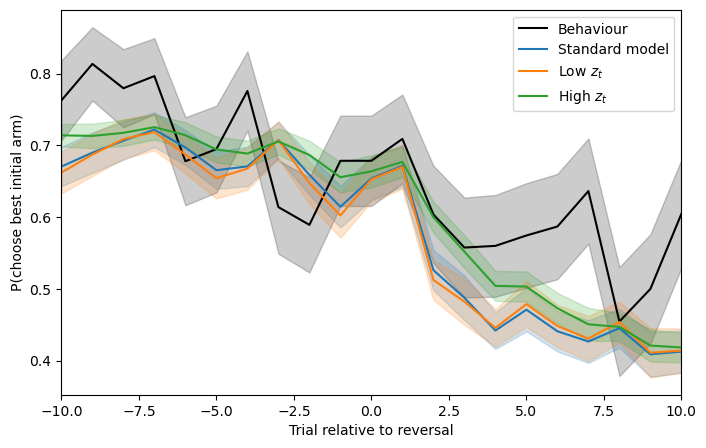

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
reload(rev)

reversal_data = rev.collapse_reversal_data(trials_data)
reversal_data = reversal_data.query('-10 <= reversal_trial_index <= 10')

sns.lineplot(reversal_data,
             x='reversal_trial_index',
             y='choice_initial',
             errorbar='se', ax=ax, color='black',
             label='Behaviour')
sns.lineplot(reversal_data,
             x='reversal_trial_index',
             y='prob_initial',
             errorbar='se', ax=ax, color='tab:blue',
             label='Standard model')

prediction_labels = ['Low $z_t$', 'High $z_t$']
prediction_colors = ['tab:orange', 'tab:green']
for df, label, color in zip(trials_data_files, prediction_labels, prediction_colors):
    reversal_df = rev.collapse_reversal_data(df)
    reversal_df = reversal_df.query('-10 <= reversal_trial_index <= 10')
    sns.lineplot(reversal_df,
                 x='reversal_trial_index',
                 y='prob_initial',
                 errorbar='se', ax=ax, color=color,
                 label=label)

ax.set(xlabel='Trial relative to reversal',
       ylabel='P(choose best initial arm)',
       xlim=(-10, 10))
ax.legend()


In [64]:
# Run held-out reversal analysis across all subjects for one model_id
reload(rev)

analysis_model_id = model_id
selected_models = best_model_df.query(
    'model_id == @analysis_model_id'
).reset_index(drop=True)

all_reversal_data = []

for _, model_row in selected_models.iterrows():
    subject_trials = analysis.load_data(model_row.trials_data_path)
    subject_model = analysis.load_data(model_row.model_pickle_path)
    z_low, z_high = subject_trials.gate_update_1.quantile([0.01, 0.99]).values
    subject_trials = subject_trials.query('split=="eval"')
    model_trials = {
        'Standard model': subject_trials,
    }
    for z, label in [(z_low, 'Low $z_t$'), (z_high, 'High $z_t$')]:
        z_tensor = torch.tensor(
            z, dtype=torch.float32
        ).unsqueeze(0).unsqueeze(0)
        fixed_gates = {'z_t': z_tensor}
        model_trials[label] = rev._run_model_on_trials_data(
            subject_model,
            subject_trials,
            fixed_gates=fixed_gates,
        )

    for condition, condition_trials in model_trials.items():
        condition_data = rev.collapse_reversal_data(condition_trials)
        condition_data = condition_data.query(
            'split == "eval" and -20 <= reversal_trial_index <= 20'
        ).copy()
        condition_data['subject_id'] = model_row.subject_id
        condition_data['model_id'] = model_row.model_id
        condition_data['outer_loop_n'] = model_row.outer_loop_n
        condition_data['condition'] = condition
        all_reversal_data.append(condition_data)

all_reversal_data = pd.concat(all_reversal_data, ignore_index=True)
print(
    f'Analysed {len(selected_models)} held-out outer-fold models and '
    f'{len(all_reversal_data)} aligned rows.'
)


Analysed 110 held-out outer-fold models and 112722 aligned rows.


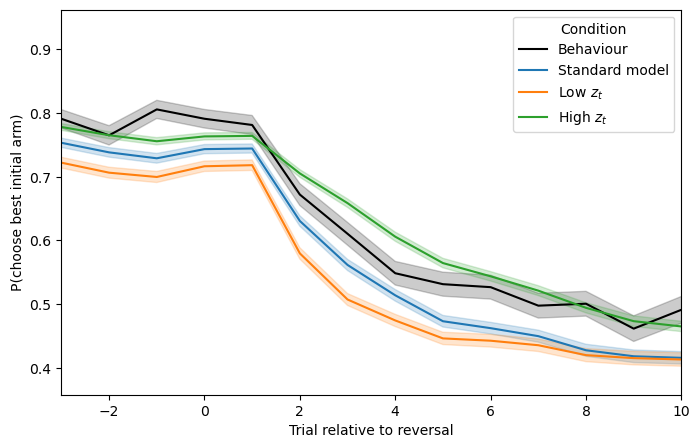

In [48]:

fig, ax = plt.subplots(figsize=(8, 5))
behaviour_data = all_reversal_data.query(
    'condition == "Standard model" and forced_choice == 0'
)
sns.lineplot(
    behaviour_data,
    x='reversal_trial_index',
    y='choice_initial',
    errorbar='se',
    ax=ax,
    color='black',
    label='Behaviour',
)

prediction_colors = {
    'Standard model': 'tab:blue',
    'Low $z_t$': 'tab:orange',
    'High $z_t$': 'tab:green',
}
for condition, color in prediction_colors.items():
    prediction_data = all_reversal_data.query(
        'condition == @condition and forced_choice == 0'
    )
    sns.lineplot(
        prediction_data,
        x='reversal_trial_index',
        y='prob_initial',
        errorbar='se',
        ax=ax,
        color=color,
        label=condition,
    )

ax.set(
    xlabel='Trial relative to reversal',
    ylabel='P(choose best initial arm)',
    xlim=(-3, 10),
)
ax.legend(title='Condition')


<Axes: xlabel='reversal_trial_index', ylabel='choice_initial'>

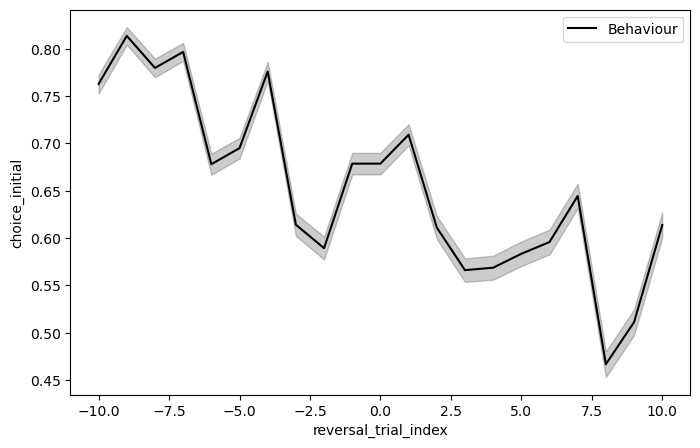

In [154]:
subject_data = all_reversal_data.query('subject_id== "WS05"')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(subject_data, x='reversal_trial_index', y='choice_initial', 
             errorbar='se', ax=ax, color='black', label='Behaviour')


In [31]:
behaviour_data.groupby('subject_id').count()

,hidden_1,hidden_2,gate_update_1,forced_choice,choice,outcome,good_poke,session_folder_name,session_trial_idx,sequence_block_idx,...,prob_A,prob_B,split,is_reversal,reversal_trial_index,reversal_type,choice_initial,prob_initial,model_id,condition
subject_id,,,,,,,,,,,,,,,,,,,,,
WS01,18230,18230,18230,18230,18230,18230,18230,18230,18230,17600,...,18220,18220,18230,18230,18230,18230,18230,18220,18230,18230
WS02,21080,21080,21080,21080,21080,21080,21080,21080,21080,20470,...,21070,21070,21080,21080,21080,21080,21080,21070,21080,21080
WS05,15200,15200,15200,15200,15200,15200,15200,15200,15200,14220,...,15180,15180,15200,15200,15200,15200,15200,15180,15200,15200
WS08,27310,27310,27310,27310,27310,27310,27310,27310,27310,26410,...,27290,27290,27310,27310,27310,27310,27310,27290,27310,27310
WS09,19500,19500,19500,19500,19500,19500,19500,19500,19500,18730,...,19490,19490,19500,19500,19500,19500,19500,19490,19500,19500
WS10,29590,29590,29590,29590,29590,29590,29590,29590,29590,28950,...,29540,29540,29590,29590,29590,29590,29590,29540,29590,29590
WS13,35760,35760,35760,35760,35760,35760,35760,35760,35760,35320,...,35760,35760,35760,35760,35760,35760,35760,35760,35760,35760
WS14,34610,34610,34610,34610,34610,34610,34610,34610,34610,33570,...,34610,34610,34610,34610,34610,34610,34610,34610,34610,34610
WS16,27890,27890,27890,27890,27890,27890,27890,27890,27890,27290,...,27870,27870,27890,27890,27890,27890,27890,27870,27890,27890


Behaviour at reversal (reversal_trial_index == 0):
 mean_across_subjects
             0.428539

Mean behaviour over the plotted window:
0.516770740282645


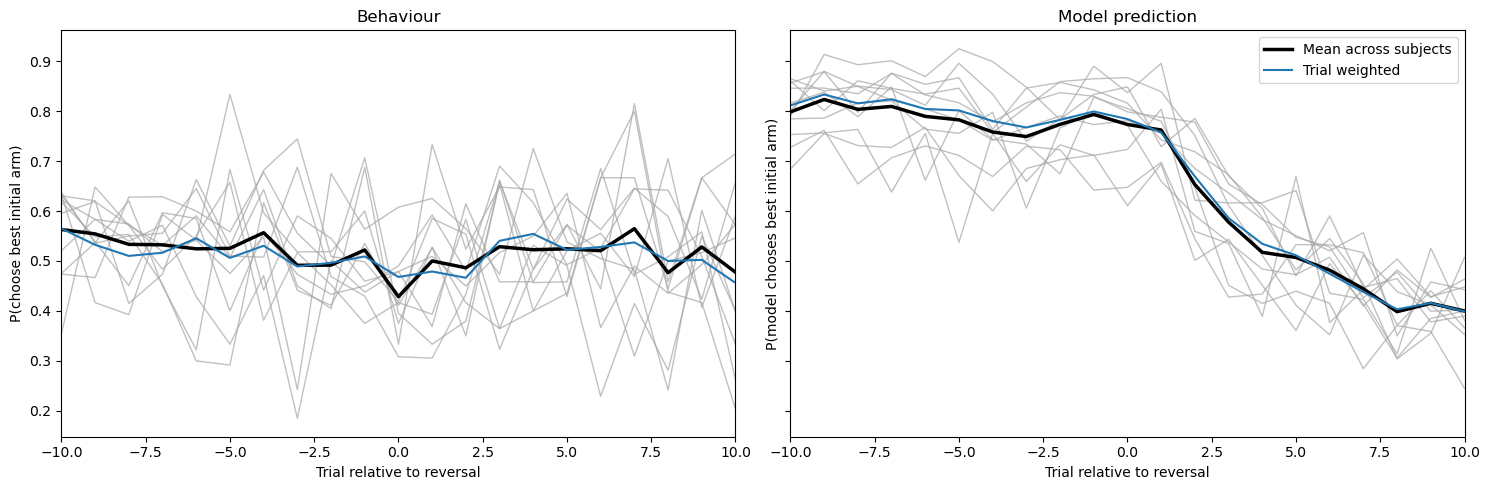

In [38]:
# Compare weighting schemes for behaviour and model predictions
behaviour_data = all_reversal_data.query(
    'condition == "Standard model" and forced_choice == 1'
).copy()

# Outer-fold rows duplicate the same subject behaviour. Collapse those rows,
# then average sessions equally within each subject.
session_level = (
    behaviour_data
    .groupby(
        ['subject_id', 'session_folder_name', 'reversal_trial_index'],
        as_index=False,
    )[['choice_initial', 'prob_initial']]
    .mean()
)
subject_level = (
    session_level
    .groupby(['subject_id', 'reversal_trial_index'], as_index=False)
    .mean(numeric_only=True)
)

trial_weighted = (
    behaviour_data
    .groupby('reversal_trial_index', as_index=False)[
        ['choice_initial', 'prob_initial']
    ]
    .mean()
)
subject_weighted = (
    subject_level
    .groupby('reversal_trial_index', as_index=False)[
        ['choice_initial', 'prob_initial']
    ]
    .mean()
)

print('Behaviour at reversal (reversal_trial_index == 0):')
print(
    subject_weighted.query('reversal_trial_index == 0')
    [['choice_initial']]
    .rename(columns={'choice_initial': 'mean_across_subjects'})
    .to_string(index=False)
)
print('\nMean behaviour over the plotted window:')
print(
    subject_weighted
    .query('-10 <= reversal_trial_index <= 10')['choice_initial']
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
plot_window = '-10 <= reversal_trial_index <= 10'

for subject_id, subject_data in subject_level.groupby('subject_id'):
    subject_data = subject_data.query(plot_window)
    axes[0].plot(
        subject_data['reversal_trial_index'],
        subject_data['choice_initial'],
        color='0.65',
        linewidth=1,
        alpha=0.7,
    )
    axes[1].plot(
        subject_data['reversal_trial_index'],
        subject_data['prob_initial'],
        color='0.65',
        linewidth=1,
        alpha=0.7,
    )

subject_plot = subject_weighted.query(plot_window)
trial_plot = trial_weighted.query(plot_window)
for axis, value_column, ylabel in [
    (axes[0], 'choice_initial', 'P(choose best initial arm)'),
    (axes[1], 'prob_initial', 'P(model chooses best initial arm)'),
]:
    axis.plot(
        subject_plot['reversal_trial_index'],
        subject_plot[value_column],
        color='black',
        linewidth=2.5,
        label='Mean across subjects',
    )
    axis.plot(
        trial_plot['reversal_trial_index'],
        trial_plot[value_column],
        color='tab:blue',
        linewidth=1.5,
        label='Trial weighted',
    )
    axis.set(
        xlabel='Trial relative to reversal',
        ylabel=ylabel,
        xlim=(-10, 10),
    )

axes[0].set_title('Behaviour')
axes[1].set_title('Model prediction')
axes[1].legend()
fig.tight_layout()


In [44]:
# Check held-out filtering and reversal recoding
heldout_reversal_data = []
for _, model_row in selected_models.iterrows():
    subject_trials = analysis.load_data(model_row.trials_data_path)
    condition_data = rev.collapse_reversal_data(subject_trials)
    condition_data = condition_data.query(
        'split == "eval" and -10 <= reversal_trial_index <= 10'
    ).copy()
    condition_data['subject_id'] = model_row.subject_id
    condition_data['model_id'] = model_row.model_id
    condition_data['outer_loop_n'] = model_row.outer_loop_n
    heldout_reversal_data.append(condition_data)

prediction_check = pd.concat(heldout_reversal_data, ignore_index=True)
print(
    f'Held-out rows: {len(prediction_check)}; '
    f'subjects: {prediction_check.subject_id.nunique()}; '
    f'model folds: {prediction_check[["subject_id", "outer_loop_n"]].drop_duplicates().shape[0]}'
)

forced_summary = (
    prediction_check
    .groupby('forced_choice')[['choice_initial', 'prob_initial']]
    .agg(['mean', 'count'])
)
print('Choice and prediction by target forced-choice status:')
print(forced_summary)

print('\nAt reversal (reversal_trial_index == 0):')
print(
    prediction_check
    .query('reversal_trial_index == 0')
    .groupby('forced_choice')[['choice_initial', 'prob_initial']]
    .mean()
)

# Verify that the collapsed recoding is equivalent to selecting the arm that
# was good before the reversal, for both choices and shifted predictions.
for reversal_type, expected_initial_best in [('LR', 0), ('RL', 1)]:
    subset = prediction_check.query('reversal_type == @reversal_type')
    choice_expected = (
        subset['choice'] == expected_initial_best
    ).astype(float)
    probability_column = 'prob_A' if expected_initial_best == 0 else 'prob_B'
    probability_expected = subset[probability_column]
    print(
        f'{reversal_type}: choice recoding matches = '
        f'{np.array_equal(subset.choice_initial.to_numpy(), choice_expected.to_numpy())}; '
        f'prediction recoding matches = '
        f'{np.allclose(subset.prob_initial, probability_expected, equal_nan=True)}'
    )


Held-out rows: 20919; subjects: 11; model folds: 110
Choice and prediction by target forced-choice status:
              choice_initial        prob_initial       
                        mean  count         mean  count
forced_choice                                          
0                   0.719286  15685     0.658713  15685
1                   0.514329   5234     0.681576   5234

At reversal (reversal_trial_index == 0):
               choice_initial  prob_initial
forced_choice                              
0                    0.792041      0.743564
1                    0.474308      0.783323
LR: choice recoding matches = True; prediction recoding matches = True
RL: choice recoding matches = True; prediction recoding matches = True


# Computational motif in weights

<Axes: xlabel='hidden_1', ylabel='hidden_2'>

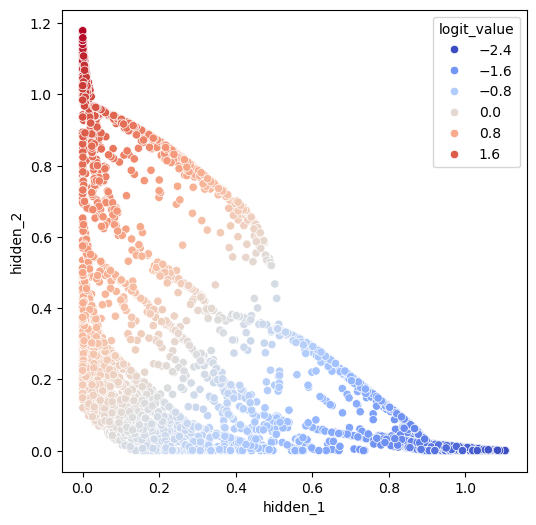

In [15]:
# let's get a 'reference' model that we align all other subject models to.
# single subject example
subject_id="WS20"
model_id = "2_unit_monoGRU_relu_unipolar_forced_ndb"
outer_loop_n = 10
select_df = best_model_df.query(f"subject_id=='{subject_id}' and model_id=='{model_id}' and outer_loop_n=={outer_loop_n}")

fig, ax = plt.subplots(1,1,figsize=(6,6))
trials_data = analysis.load_data(select_df.trials_data_path.iloc[0])
model = analysis.load_data(select_df.model_pickle_path.iloc[0])
sns.scatterplot(trials_data, x= 'hidden_1',y='hidden_2', hue='logit_value',palette='coolwarm')

In [34]:
# Average parameters across all outer-loop models for one subject and model_id
import copy


def average_subject_model_parameters(best_model_df, subject_id, model_id, reference_model):
    if subject_id == "all":
        selected_models = best_model_df.query(
            'model_id == @model_id'
        ).reset_index(drop=True)
    else:
        selected_models = best_model_df.query(
            'subject_id==@subject_id and model_id == @model_id'
    ).reset_index(drop=True)
    if selected_models.empty:
        raise ValueError(
            f'No models found for subject_id={subject_id!r}, '
            f'model_id={model_id!r}'
        )

    models = [
        analysis.load_data(path)
        for path in selected_models.model_pickle_path
    ]
    #align models
    for i, model in enumerate(models):
        if not isinstance(model, torch.nn.Module):
            raise ValueError(
                f'Model at index {i} is not a torch.nn.Module instance.'
            )
        model_aligned, _ = mech_var.align_rnns(reference_model, model)
        models[i] = model_aligned

    reference_state = models[0].state_dict()

    for current_model in models[1:]:
        current_state = current_model.state_dict()
        if set(current_state) != set(reference_state):
            raise ValueError('Models do not have matching state_dict keys.')
        for parameter_name in reference_state:
            if current_state[parameter_name].shape != reference_state[parameter_name].shape:
                raise ValueError(
                    f'Mismatched shape for {parameter_name!r}.'
                )

    averaged_state = {}
    for parameter_name, reference_value in reference_state.items():
        values = [
            current_model.state_dict()[parameter_name]
            for current_model in models
        ]
        if reference_value.is_floating_point() or reference_value.is_complex():
            averaged_state[parameter_name] = torch.stack(values).mean(dim=0)
        else:
            if not all(torch.equal(value, values[0]) for value in values[1:]):
                raise ValueError(
                    f'Non-floating state {parameter_name!r} differs across models.'
                )
            averaged_state[parameter_name] = values[0].clone()

    averaged_model = copy.deepcopy(models[0])
    averaged_model.load_state_dict(averaged_state)
    return averaged_model, selected_models


averaged_model, averaged_model_rows = average_subject_model_parameters(
    best_model_df,
    subject_id='all',
    model_id=model_id,
    reference_model=model
)


print(
    f'Averaged {len(averaged_model_rows)} models across all models'
)

for parameter_name, parameter_value in averaged_model.named_parameters():
    print(f'{parameter_name}: {parameter_value}')

Averaged 110 models across all models
rnn.W_ih: Parameter containing:
tensor([[-0.1149, -0.1759],
        [ 0.6289, -1.0903],
        [ 0.8535,  0.9508]], requires_grad=True)
rnn.W_hh: Parameter containing:
tensor([[ 0.2358, -0.0663],
        [-0.3941,  0.2891]], requires_grad=True)
rnn.W_iz: Parameter containing:
tensor([[ 0.2068],
        [ 0.1249],
        [-0.8606]], requires_grad=True)
rnn.W_hz: Parameter containing:
tensor([[-1.4930],
        [-0.8290]], requires_grad=True)
rnn.bias_h: Parameter containing:
tensor([-0.5586,  0.0109], requires_grad=True)
rnn.bias_z: Parameter containing:
tensor(0.1887, requires_grad=True)
rnn.hidden_0: Parameter containing:
tensor([0.4469, 0.4132], requires_grad=True)
rnn.z_0: Parameter containing:
tensor([-1.7278e-05], requires_grad=True)
decoder.weight: Parameter containing:
tensor([[-1.1232,  1.2573],
        [ 1.1305, -1.2491]], requires_grad=True)


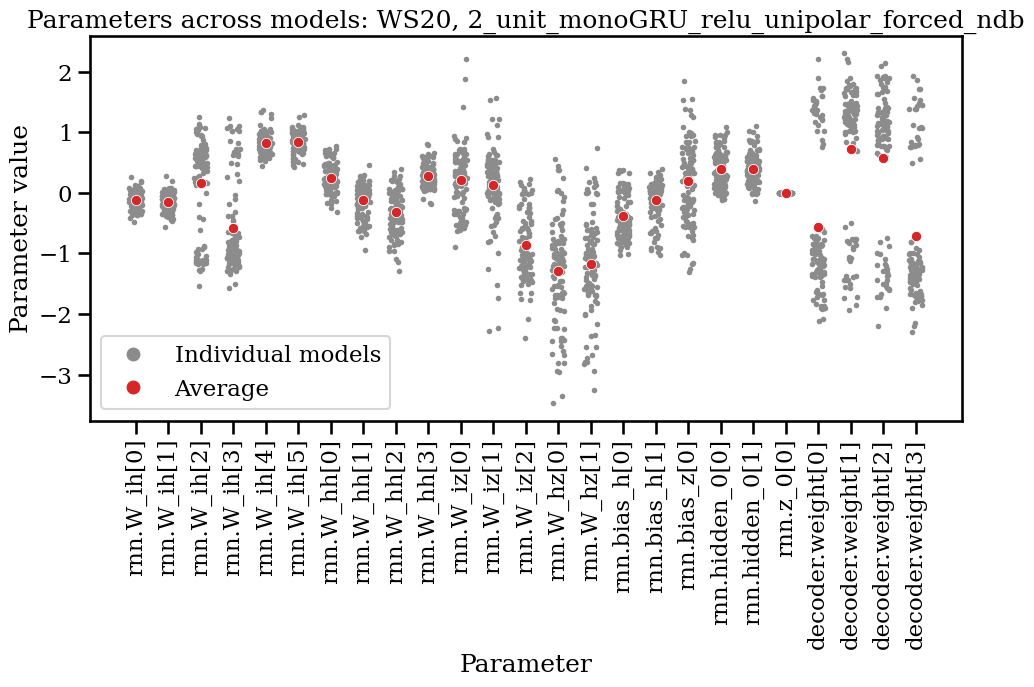

In [29]:
# Visualise individual parameters and their across-model averages
from matplotlib.lines import Line2D

parameter_records = []

for model_number, model_path in enumerate(averaged_model_rows.model_pickle_path):
    current_model = analysis.load_data(model_path)
    for parameter_name, parameter in current_model.named_parameters():
        for parameter_index, value in enumerate(parameter.detach().cpu().reshape(-1).numpy()):
            parameter_records.append({
                'parameter': f'{parameter_name}[{parameter_index}]',
                'model_number': model_number,
                'value': value,
            })

parameter_data = pd.DataFrame(parameter_records)
parameter_means = (
    parameter_data
    .groupby('parameter', as_index=False)['value']
    .mean()
    .rename(columns={'value': 'average_value'})
)

fig, ax = plt.subplots(
    figsize=(max(10, 0.45 * parameter_data['parameter'].nunique()), 5)
)
sns.stripplot(
    parameter_data,
    x='parameter',
    y='value',
    color='0.55',
    size=4,
    jitter=0.2,
    ax=ax,
)
sns.scatterplot(
    parameter_means,
    x='parameter',
    y='average_value',
    color='tab:red',
    s=55,
    zorder=3,
    ax=ax,
)
ax.set(
    xlabel='Parameter',
    ylabel='Parameter value',
    title=f'Parameters across models: {subject_id}, {model_id}',
)
ax.tick_params(axis='x', rotation=90)
ax.legend(
    handles=[
        Line2D([], [], marker='o', linestyle='', color='0.55', label='Individual models'),
        Line2D([], [], marker='o', linestyle='', color='tab:red', label='Average'),
    ]
)


In [30]:
for name, p in model.named_parameters():
    print(f'{name}: {p}')

rnn.W_ih: Parameter containing:
tensor([[-0.2318, -0.0325],
        [ 0.6435, -0.7895],
        [ 0.8820,  0.8883]], requires_grad=True)
rnn.W_hh: Parameter containing:
tensor([[-0.0504, -0.9398],
        [-1.2822,  0.0682]], requires_grad=True)
rnn.W_iz: Parameter containing:
tensor([[ 0.8838],
        [ 0.2908],
        [-1.4450]], requires_grad=True)
rnn.W_hz: Parameter containing:
tensor([[-1.6393],
        [-1.6106]], requires_grad=True)
rnn.bias_h: Parameter containing:
tensor([-0.3650,  0.2104], requires_grad=True)
rnn.bias_z: Parameter containing:
tensor(0.7258, requires_grad=True)
rnn.hidden_0: Parameter containing:
tensor([0.3476, 0.3893], requires_grad=True)
rnn.z_0: Parameter containing:
tensor([-0.0008], requires_grad=True)
decoder.weight: Parameter containing:
tensor([[-1.0876,  0.9109],
        [ 1.0878, -0.9109]], requires_grad=True)


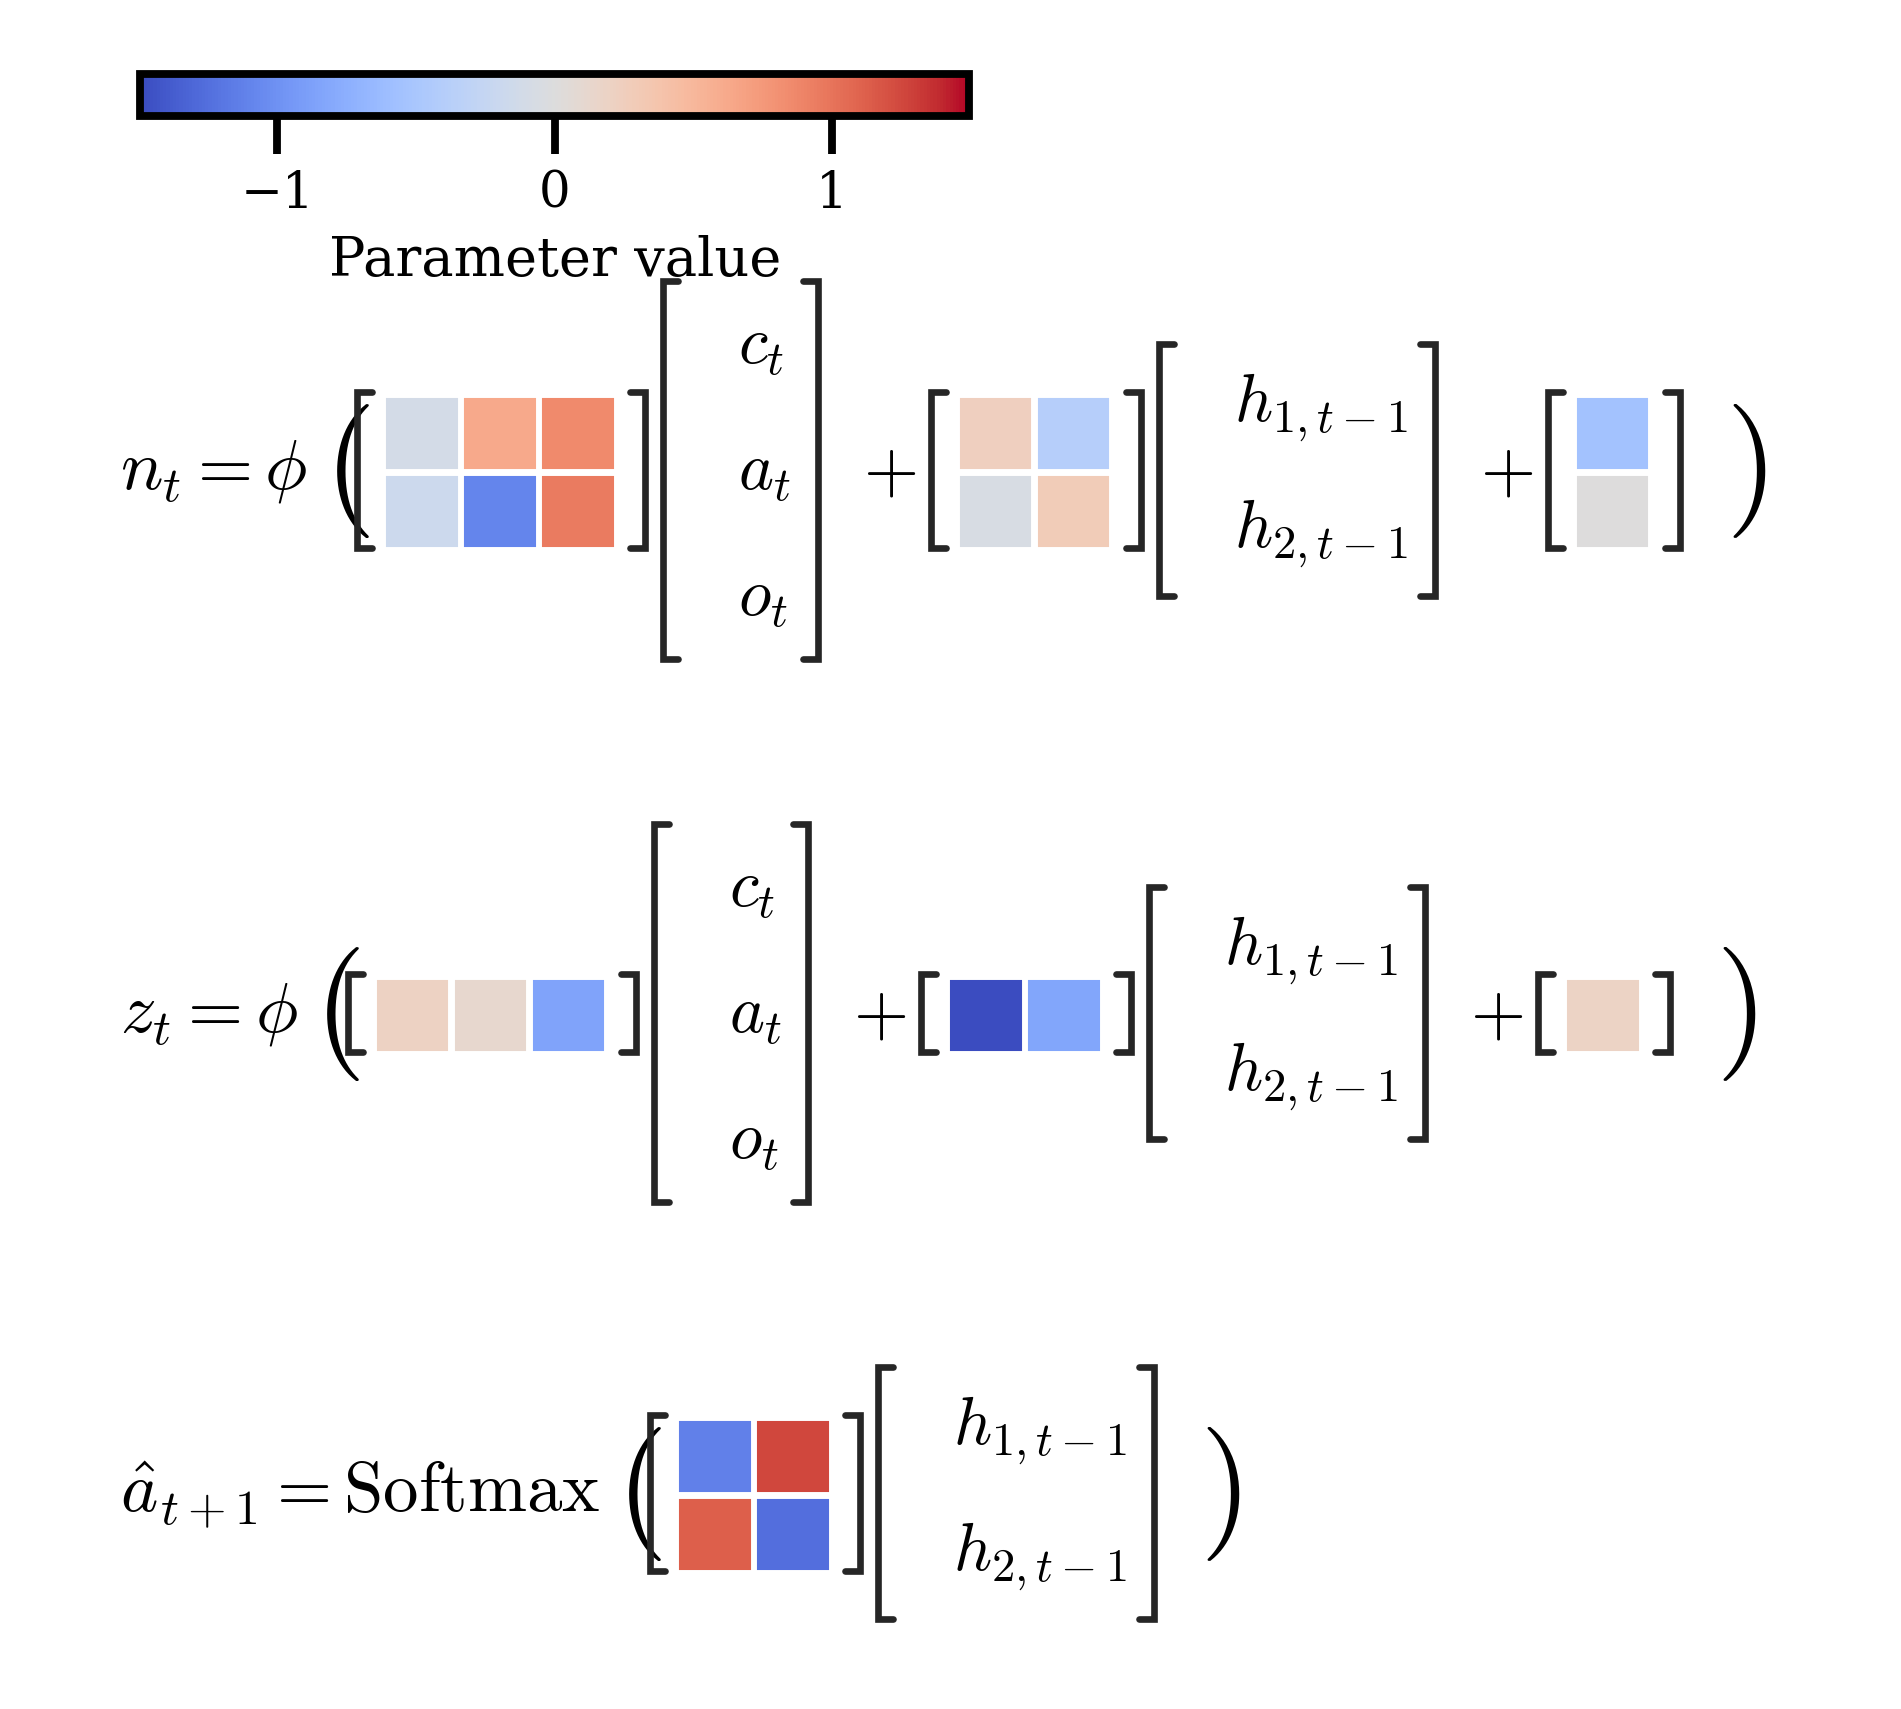

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, PathPatch
from matplotlib.path import Path
from matplotlib.colors import TwoSlopeNorm


def plot_model_equations(model, equations, cmap_name="coolwarm", cell=0.26,
                          row_h=0.42, fontsize=17, vec_fontsize=16, x0=0.3,
                          row_gap=0.55, colorbar=True, use_latex_font=True,
                          icon_pad=0.09, vector_pad=0.09, vector_text_pad=0.16,
                          dpi=300, colorbar_width=0.45, colorbar_height=0.14,
                          colorbar_fontsize=12):
    """
    Render a set of gate/update equations for `model`, with each weight
    matrix drawn inline as a small colour-coded icon on a shared,
    zero-centred colour scale (matching your existing parameter plot).

    Parameters
    ----------
    model : any object with .named_parameters() yielding (name, tensor)
        (a torch.nn.Module works directly).
    equations : list of dicts, one per equation row, each:
        {
          "lhs": "n_t",                 # left-hand side, mathtext (no $)
          "activation": r"\\phi",       # wrapped in ( ... ); plain words
                                         # like "Softmax" are auto-\\mathrm'd
          "terms": [
              {"param": "rnn.W_ih", "transpose": True,
               "vector_labels": ["c_t", "a_t", "o_t"]},
              {"param": "rnn.W_hh", "transpose": True,
               "vector_labels": ["h_{1,t-1}", "h_{2,t-1}"]},
              {"param": "rnn.bias_h"},   # lone icon, no vector -> bias term
          ],
        }
        "transpose" is needed whenever the stored weight is (in, out)
        rather than the (out, in) convention used for W @ x in the
        equation (torch.nn.Linear-style weights are already (out, in)
        and don't need it). Scalars and 1-D params (biases) are reshaped
        automatically.
    cmap_name, cell, row_h, fontsize, vec_fontsize, x0, row_gap : layout knobs.
    colorbar : whether to draw a shared colour scale at the top.
    use_latex_font : if True (default), render all text with matplotlib's
        Computer Modern mathtext font ('cm'), which closely matches real
        LaTeX output, instead of the default sans-serif mathtext.
    icon_pad : gap (inches) between a matrix icon's cells and its brackets.
    vector_pad : gap (inches) between a vector's text and its brackets.
    vector_text_pad : left-inset (inches) of vector labels from the
        left bracket (keep >= vector_pad so labels clear the bracket tick).
    dpi : resolution of the returned figure (affects both plt.show() and
        any savefig() that doesn't override dpi itself).
    colorbar_width, colorbar_height : size of the colour scale, as a
        fraction of the figure width / an absolute size in inches.
    colorbar_fontsize : font size for the colorbar's tick labels and title
        (the title is drawn 1pt larger).

    Returns
    -------
    matplotlib.figure.Figure
    """
    params = dict(model.named_parameters())

    if use_latex_font:
        # Persists for the session (mathtext is rendered lazily, at
        # show()/savefig() time, so scoping this to only the function
        # body wouldn't survive until then). Call
        # matplotlib.rcdefaults() to undo, or pass use_latex_font=False.
        plt.rcParams.update({"mathtext.fontset": "cm", "font.family": "serif"})

    # ---- resolve every referenced parameter into a plain 2D numpy array ----
    def resolve(term):
        p = params[term["param"]].detach().cpu().numpy()
        if p.ndim == 0:
            p = p.reshape(1, 1)
        elif p.ndim == 1:
            p = p.reshape(-1, 1)
        if term.get("transpose") and p.ndim == 2:
            p = p.T
        return p

    for eq in equations:
        for term in eq["terms"]:
            term["_matrix"] = resolve(term)

    all_vals = np.concatenate(
        [t["_matrix"].ravel() for eq in equations for t in eq["terms"]]
    )
    vmax = float(np.abs(all_vals).max())
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    # ---- low-level drawing helpers (inch-based: 1 data unit == 1 inch) ----
    def width(ax, artist):
        fig = ax.figure
        fig.canvas.draw()
        b = artist.get_window_extent(renderer=fig.canvas.get_renderer())
        (x0_, _), (x1_, _) = ax.transData.inverted().transform([[b.x0, b.y0], [b.x1, b.y1]])
        return x1_ - x0_

    def bracket(ax, x, y0, y1, side):
        t = 0.05 if side == "left" else -0.05
        p = Path([(x + t, y1), (x, y1), (x, y0), (x + t, y0)],
                  [Path.MOVETO] + [Path.LINETO] * 3)
        ax.add_patch(PathPatch(p, fc="none", ec="0.15", lw=1.6,
                                capstyle="round", zorder=5))

    def icon(ax, x, yc, M):
        nr, nc = M.shape
        w, h = nc * cell, nr * cell
        yt = yc + h / 2
        for r in range(nr):
            for c in range(nc):
                ax.add_patch(Rectangle(
                    (x + c * cell, yt - (r + 1) * cell), cell - 0.012, cell - 0.012,
                    fc=cmap(norm(M[r, c])), ec="white", lw=0.7, zorder=4,
                ))
        bracket(ax, x - icon_pad, yt - h, yt, "left")
        bracket(ax, x + w + icon_pad, yt - h, yt, "right")
        return w + 2 * icon_pad + 0.06

    def vector(ax, x, yc, labels):
        n = len(labels)
        h = n * row_h
        yt = yc + h / 2
        texts = [
            ax.text(x + vector_text_pad, yt - (i + 0.5) * row_h, f"${l}$",
                    ha="left", va="center", fontsize=vec_fontsize, zorder=5)
            for i, l in enumerate(labels)
        ]
        w = max(width(ax, t) for t in texts) + vector_text_pad
        bracket(ax, x - vector_pad, yt - h, yt, "left")
        bracket(ax, x + w + vector_pad, yt - h, yt, "right")
        return w + 2 * vector_pad + 0.06

    def text(ax, x, yc, s, fs):
        t = ax.text(x, yc, s, ha="left", va="center", fontsize=fs, zorder=5)
        return width(ax, t) + 0.05

    def equation_row(ax, yc, lhs, terms, activation):
        act = activation if activation.lstrip().startswith("\\") or "{" in activation \
            else rf"\mathrm{{{activation}}}"
        x = x0
        x += text(ax, x, yc, f"${lhs} = {act}$", fontsize)
        x += text(ax, x, yc, "$($", fontsize * 1.9)
        for i, term in enumerate(terms):
            if i:
                x += text(ax, x, yc, "$+$", fontsize) + icon_pad
            x += icon(ax, x, yc, term["_matrix"])
            if term.get("vector_labels"):
                x += vector(ax, x, yc, term["vector_labels"])
        x += text(ax, x, yc, "$)$", fontsize * 1.9)
        return x

    # ---- vertical layout ----
    def term_height(term):
        h_icon = term["_matrix"].shape[0] * cell
        h_vec = len(term.get("vector_labels", [])) * row_h if term.get("vector_labels") else 0
        return max(h_icon, h_vec)

    row_heights = [max(term_height(t) for t in eq["terms"]) for eq in equations]
    cbar_top_gap, cbar_bottom_gap = 0.15, 0.55  # inches: above / below the bar itself
    top_margin = (cbar_top_gap + colorbar_height + cbar_bottom_gap) if colorbar else 0.2
    bottom_margin = 0.2
    total_h = sum(row_heights) + row_gap * (len(equations) - 1) + top_margin + bottom_margin

    # draw on a generously wide scratch canvas, then crop to actual content
    scratch_w = 22.0
    fig = plt.figure(figsize=(scratch_w, total_h), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(0, scratch_w)
    ax.set_ylim(0, total_h)
    ax.axis("off")

    y = total_h - top_margin
    max_x = 0.0
    for eq, rh in zip(equations, row_heights):
        yc = y - rh / 2
        x_end = equation_row(ax, yc, eq["lhs"], eq["terms"], eq["activation"])
        max_x = max(max_x, x_end)
        y -= rh + row_gap

    final_w = max_x + 0.3
    fig.set_size_inches(final_w, total_h)
    ax.set_xlim(0, final_w)

    if colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cax = fig.add_axes([0.06, 1 - (cbar_top_gap + colorbar_height) / total_h,
                             colorbar_width, colorbar_height / total_h])
        cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
        cbar.set_label("Parameter value", fontsize=colorbar_fontsize + 1)
        cbar.ax.tick_params(labelsize=colorbar_fontsize)

    return fig



# --------------------------------------------------------------------------
# self-test with fake parameters shaped like the model in the prompt
# --------------------------------------------------------------------------

equations = [
    dict(lhs="n_t", activation=r"\phi", terms=[
        dict(param="rnn.W_ih", transpose=True, vector_labels=["c_t", "a_t", "o_t"]),
        dict(param="rnn.W_hh", transpose=True, vector_labels=["h_{1,t-1}", "h_{2,t-1}"]),
        dict(param="rnn.bias_h"),
    ]),
    dict(lhs="z_t", activation=r"\phi", terms=[
        dict(param="rnn.W_iz", transpose=True, vector_labels=["c_t", "a_t", "o_t"]),
        dict(param="rnn.W_hz", transpose=True, vector_labels=["h_{1,t-1}", "h_{2,t-1}"]),
        dict(param="rnn.bias_z"),
    ]),
    dict(lhs=r"\hat{a}_{t+1}", activation="Softmax", terms=[
        dict(param="decoder.weight", vector_labels=["h_{1,t-1}", "h_{2,t-1}"]),
    ]),
]


plot_model_equations(averaged_model, equations)
plt.show()

## Dynamical systems analysis

It suffices to look at the candidate state.
We consider the dynamics under fixed inputs.


Input x = [0.0, 0.0, 0.0]
  fixed point 1: h* = [0.0, 0.2258]   (active units: 01)
      eigenvalues = [+0.068, -0.000]   spectral radius = 0.0682   -> stable

Input x = [0.0, 1.0, 0.0]
  fixed point 1: h* = [0.2651, 0.0]   (active units: 10)
      eigenvalues = [-0.050, +0.000]   spectral radius = 0.0504   -> stable

Input x = [0.0, 0.0, 1.0]
  fixed point 1: h* = [0.0, 1.1792]   (active units: 01)
      eigenvalues = [+0.068, -0.000]   spectral radius = 0.0682   -> stable

Input x = [0.0, 1.0, 1.0]
  fixed point 1: h* = [1.1048, 0.0]   (active units: 10)
      eigenvalues = [-0.050, +0.000]   spectral radius = 0.0504   -> stable


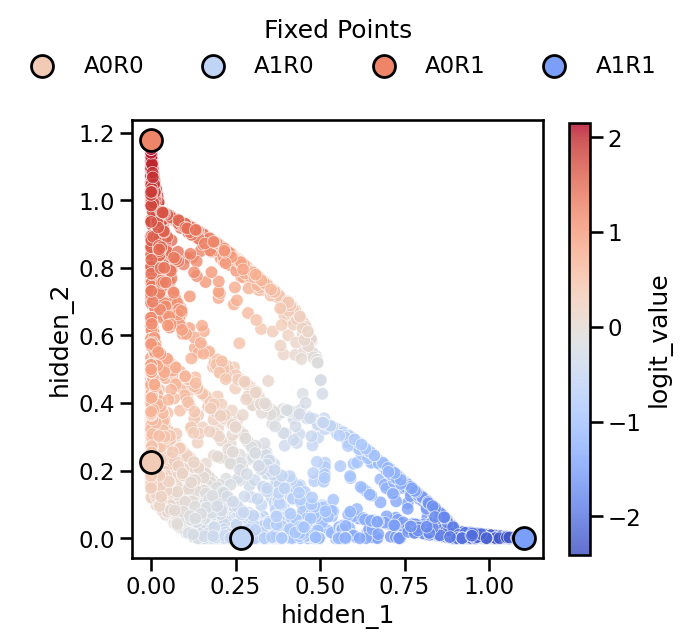

In [25]:
from NM_TinyRNN.code.measures import dynamical_stability as dysta
reload(dysta)
# let's get a 'reference' model that we align all other subject models to.
# single subject example
subject_id="WS20"
model_id = "2_unit_monoGRU_relu_unipolar_forced_ndb"
outer_loop_n = 10
select_df = best_model_df.query(f"subject_id=='{subject_id}' and model_id=='{model_id}' and outer_loop_n=={outer_loop_n}")

trials_data = analysis.load_data(select_df.trials_data_path.iloc[0])
model = analysis.load_data(select_df.model_pickle_path.iloc[0])


inputs = [[0, 0, 0], [0, 1, 0], [0, 0, 1], [0, 1, 1]]
label_key_dict = {'A0R0':(0,0,0),'A1R0':(0,1,0),'A0R1':(0,0,1),'A1R1':(0,1,1)}

results = dysta.analyze_candidate_state(model, inputs)

# Set context for larger, presentation-ready labels
sns.set_context('talk')

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

# 1. Plot background scatter points without seaborn generating a legend
sc = ax.scatter(
    trials_data['hidden_1'], 
    trials_data['hidden_2'], 
    c=trials_data['logit_value'], 
    cmap='coolwarm', 
    edgecolor='w', 
    linewidth=0.5, 
    alpha=0.8
)

# 2. Add continuous colorbar for logit_value
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('logit_value')
cp = sns.color_palette("coolwarm", n_colors=4)
color_map = {
    'A1R0': cp[1], 'A1R1': cp[0],
    'A0R0': cp[2], 'A0R1': cp[3]
}
# 3. Plot fixed points with a distinct black outline
for label, key in label_key_dict.items():
    ax.scatter(
        results[key][0]['h'][0], 
        results[key][0]['h'][1], 
        label=label, 
        s=250,
        marker='o',
        color=color_map[label],
        edgecolor='black',
        linewidth=2.0,
        zorder=5  # Ensures fixed points sit on top of background dots
    )

# 4. Set square aspect ratio
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel('hidden_1')
ax.set_ylabel('hidden_2')

# 5. Place the fixed points legend above the figure
ax.legend(
    title='Fixed Points',
    loc='lower center',
    bbox_to_anchor=(0.5, 1.05),
    ncol=4,                  # Spread items horizontally
    frameon=False,
    alignment='center'
)

plt.tight_layout()
plt.show()
